# Plot the comparison of different MSE values

In [1]:
import pandas as pd
import numpy as np
import warnings, os

warnings.filterwarnings("ignore")

file_path = "/Users/pao/Desktop/Intern/output/Asar_LLT/MSE_Table.xlsx"
df = pd.read_excel(file_path)
df

,Data,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,p,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
1,rho^2,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000
2,n,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000
3,k_AM,0.847541,0.812800,0.781430,0.858008,0.828467,0.804530,0.859705,0.850364,0.830472,0.921871,0.902416,0.883607,0.926008,0.908325,0.890693,0.925539,0.917626,0.910343
4,k_GM,0.764895,0.694016,0.633585,0.859171,0.762772,0.698426,1.300255,1.020781,0.871045,0.866931,0.799088,0.742442,0.968459,0.867092,0.794953,1.553117,1.241979,1.035274
5,k_MED,0.774474,0.695828,0.633194,0.899521,0.771350,0.692648,1.823365,1.220364,0.935555,0.888501,0.798416,0.730996,1.038106,0.889268,0.795051,2.166212,1.557494,1.168229
6,MLE,2.780612,1.180093,0.605114,5.354626,2.242809,1.093022,26.802344,10.578124,4.921985,9.145625,2.513118,1.128821,20.355791,4.932500,2.148786,100.649613,23.783156,10.415456


## Definition of function `plot_figures()`

In [2]:
import matplotlib.pyplot as plt


def plot_figures(name, start, end, plot_mle=False):
    """
    Input
    name        : Description of the data being plotted
    start       : The column index where data selection starts
    end         : The column index where data selection ends
    plot_mle    : Whether include the Maximum Likelihood Estimation (MLE) data in the plot

    Output:
    None
    """
    # Set style sheet
    plt.style.use("default")

    # Get the data
    p_values = df.iloc[0, start : end + 1].astype(int).values
    rho_values = df.iloc[1, start : end + 1].astype(float).values
    x_values = df.iloc[2, start : end + 1].astype(int).values
    k_AM_values = df.iloc[3, start : end + 1].astype(float).values
    k_GM_values = df.iloc[4, start : end + 1].astype(float).values
    k_MED_values = df.iloc[5, start : end + 1].astype(float).values
    MLE_values = df.iloc[6, start : end + 1].astype(float).values

    # Find the unique value of index 'p' and 'rho'
    unique_p_values = np.unique(p_values)[0]
    unique_rho_values = sorted(set(rho_values))

    # plot the figures
    fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=200, sharey=True)

    for i, rho in enumerate(unique_rho_values):
        mask = rho_values == rho
        x = x_values[mask]
        k_AM = k_AM_values[mask]
        k_GM = k_GM_values[mask]
        k_MED = k_MED_values[mask]
        MLE = MLE_values[mask]

        ax = axs[i]
        x_labels = [str(x_val) for x_val in x]
        ax.plot(x_labels, k_AM, label="k_AM", marker="o", linestyle="--")
        ax.plot(x_labels, k_GM, label="k_GM", marker="s", linestyle=":")
        ax.plot(x_labels, k_MED, label="k_MED", marker="^", linestyle="-.")
        if plot_mle == True:
            ax.plot(x_labels, MLE, label="MLE", marker="x", linestyle="-.")
        ax.set_title(f"$\\rho^2 = {rho}$")
        ax.set_xlabel("n")
        ax.set_xticks(x_labels)
        ax.set_xticklabels(x_labels)
        if i == 0:
            ax.set_ylabel(f"The Estimated {name}")
        ax.legend()

    output_dir = "/Users/pao/Desktop/Intern/output/Asar_LLT/"
    filename = f"{name}_p_{unique_p_values}"
    filename += "_without_MLE.png" if not plot_mle else ".png"

    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)

    suptitle_text = f"Compare the {name} value with p = {unique_p_values}"
    suptitle_text += " (without MLE)" if not plot_mle else ""
    plt.suptitle(suptitle_text, size=15)
    plt.tight_layout()
    plt.savefig(filepath)
    plt.show()
    plt.close("all")

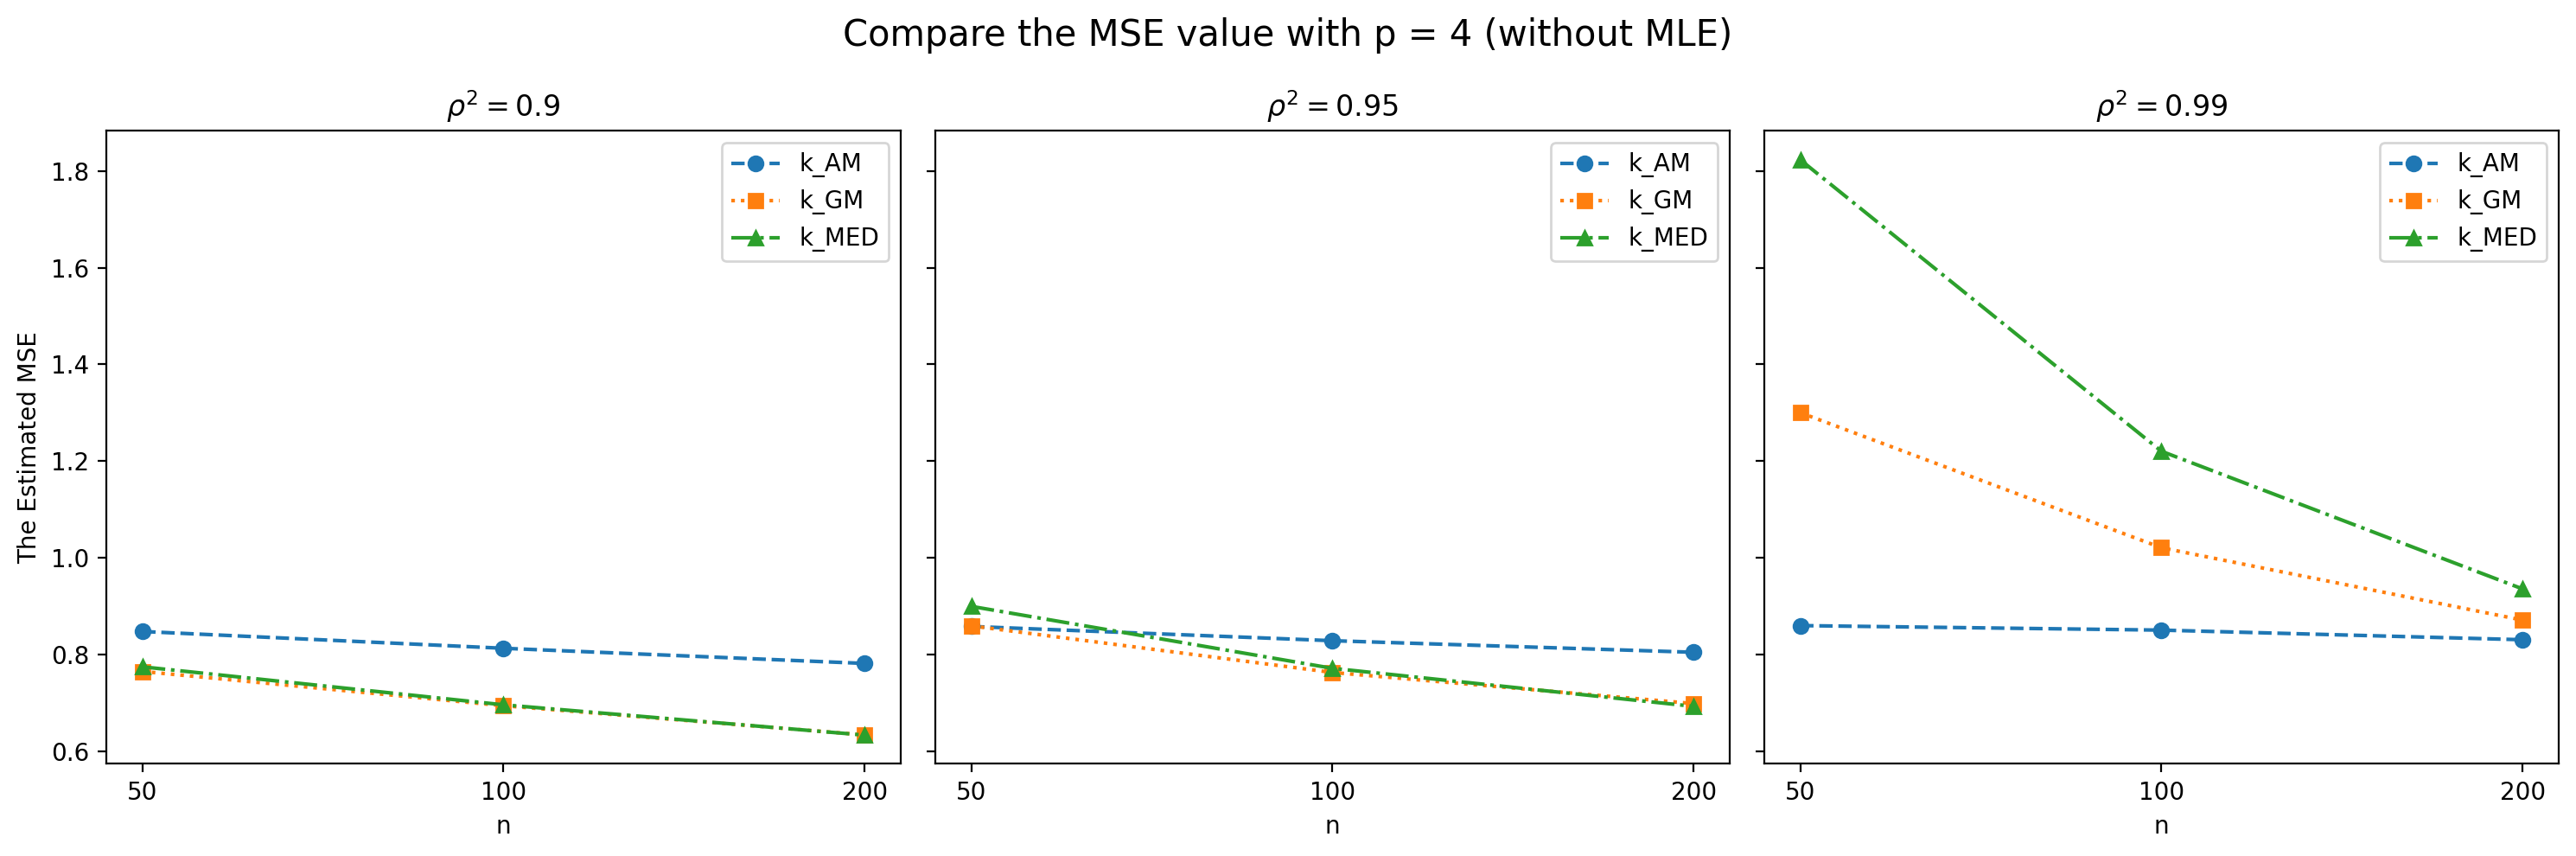

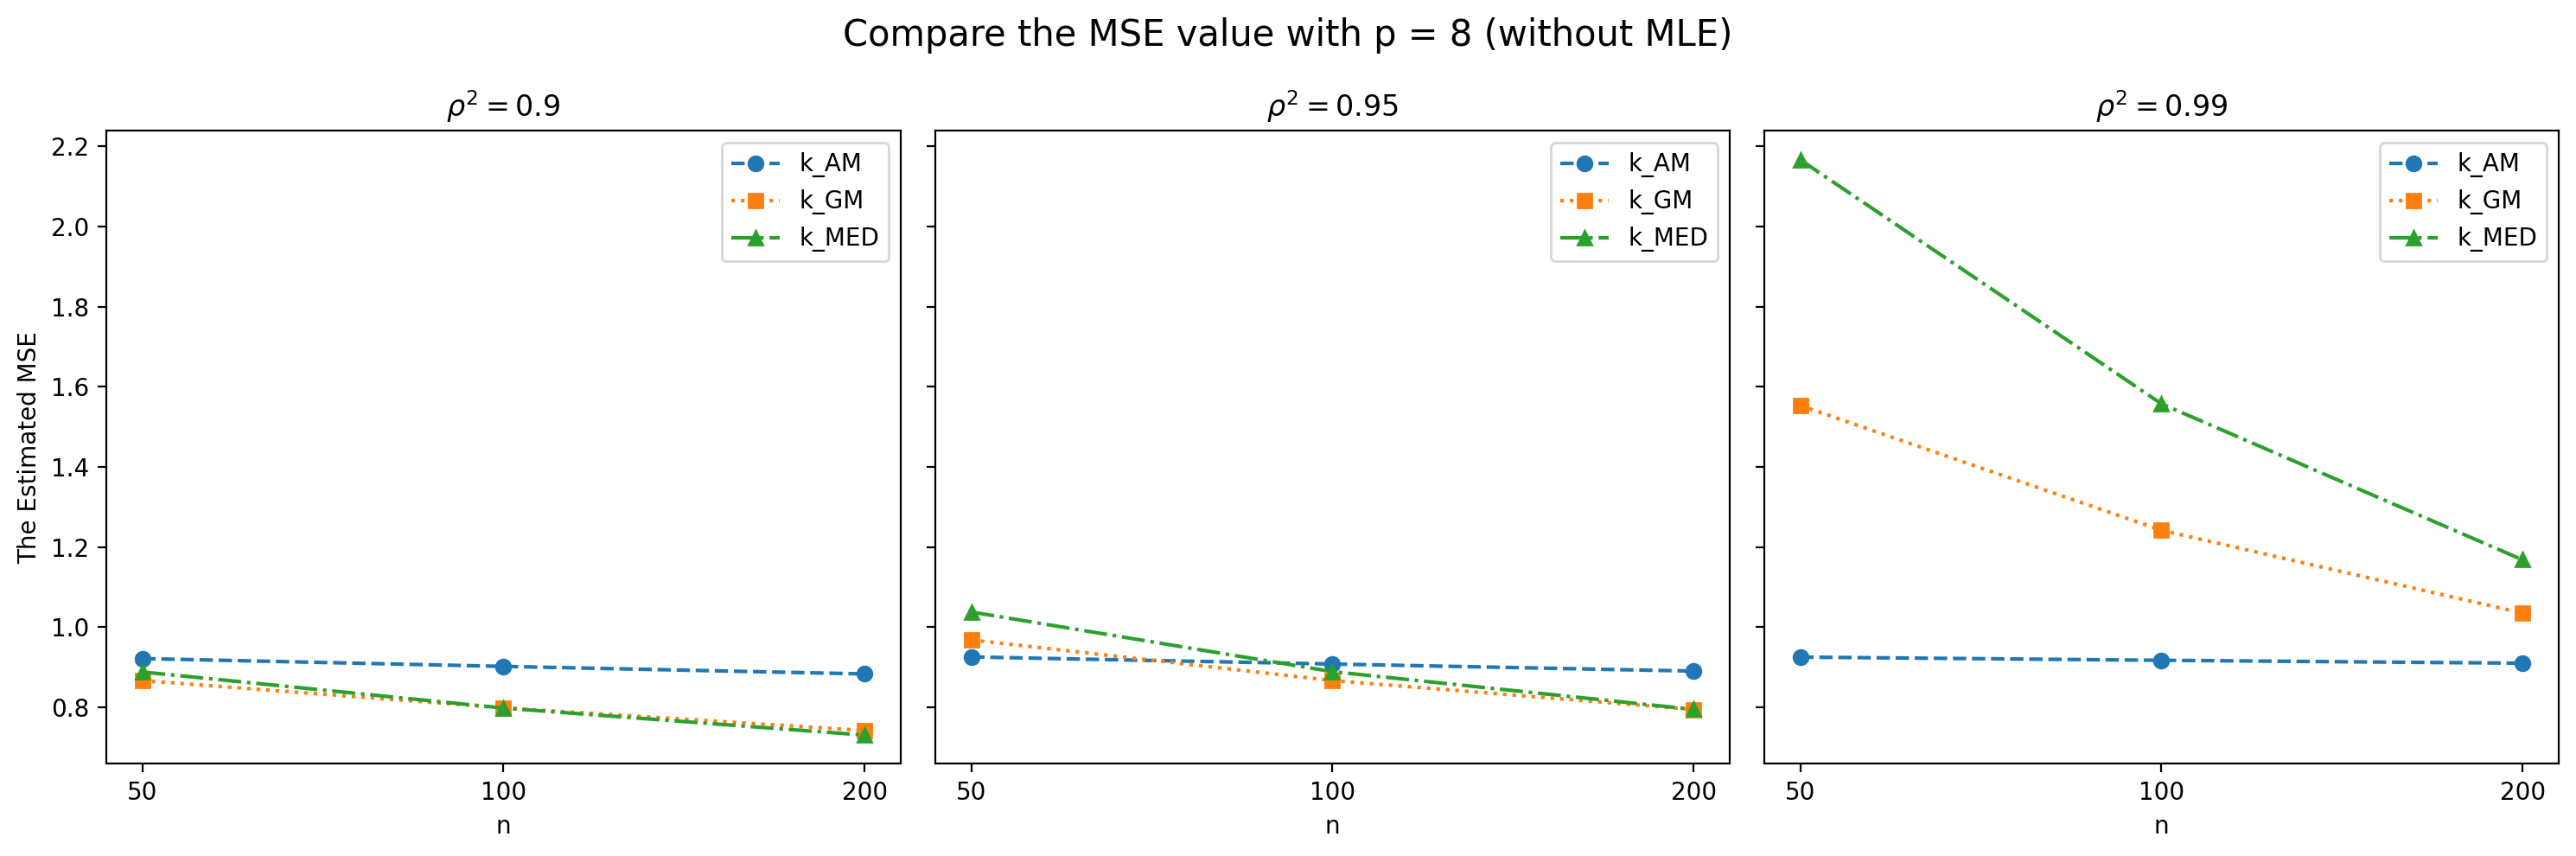

In [3]:
compare = "MSE"
ranges = [(1, 9), (10, 18)]
# plot_mle_options = [False, True]
plot_mle_options = [False]

for start, end in ranges:
    for plot_mle in plot_mle_options:
        plot_figures(compare, start, end, plot_mle)

# Plot the comparison of different MAE values

In [4]:
file_path = "/Users/pao/Desktop/Intern/output/Asar_LLT/MAE_Table.xlsx"
df = pd.read_excel(file_path)
df

,Data,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,p,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
1,rho^2,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000
2,n,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000
3,k_AM,1.722881,1.681530,1.645160,1.728685,1.697458,1.676295,1.731660,1.727601,1.708925,2.356763,2.328500,2.308765,2.367435,2.342230,2.317534,2.363181,2.360373,2.350781
4,k_GM,1.622112,1.543386,1.473885,1.706187,1.616315,1.554363,2.009590,1.832316,1.722747,2.274441,2.181837,2.110858,2.393272,2.273084,2.180654,2.926313,2.655080,2.467616
5,k_MED,1.631348,1.545557,1.471677,1.735376,1.621410,1.544813,2.254810,1.944782,1.764227,2.295488,2.179801,2.091531,2.456904,2.296264,2.177749,3.337360,2.901897,2.587944
6,MLE,2.893673,1.928319,1.382960,4.029162,2.648902,1.857533,8.981343,5.730902,3.942462,6.409252,3.756571,2.541233,9.157573,5.250664,3.487308,20.287893,11.505527,7.689569


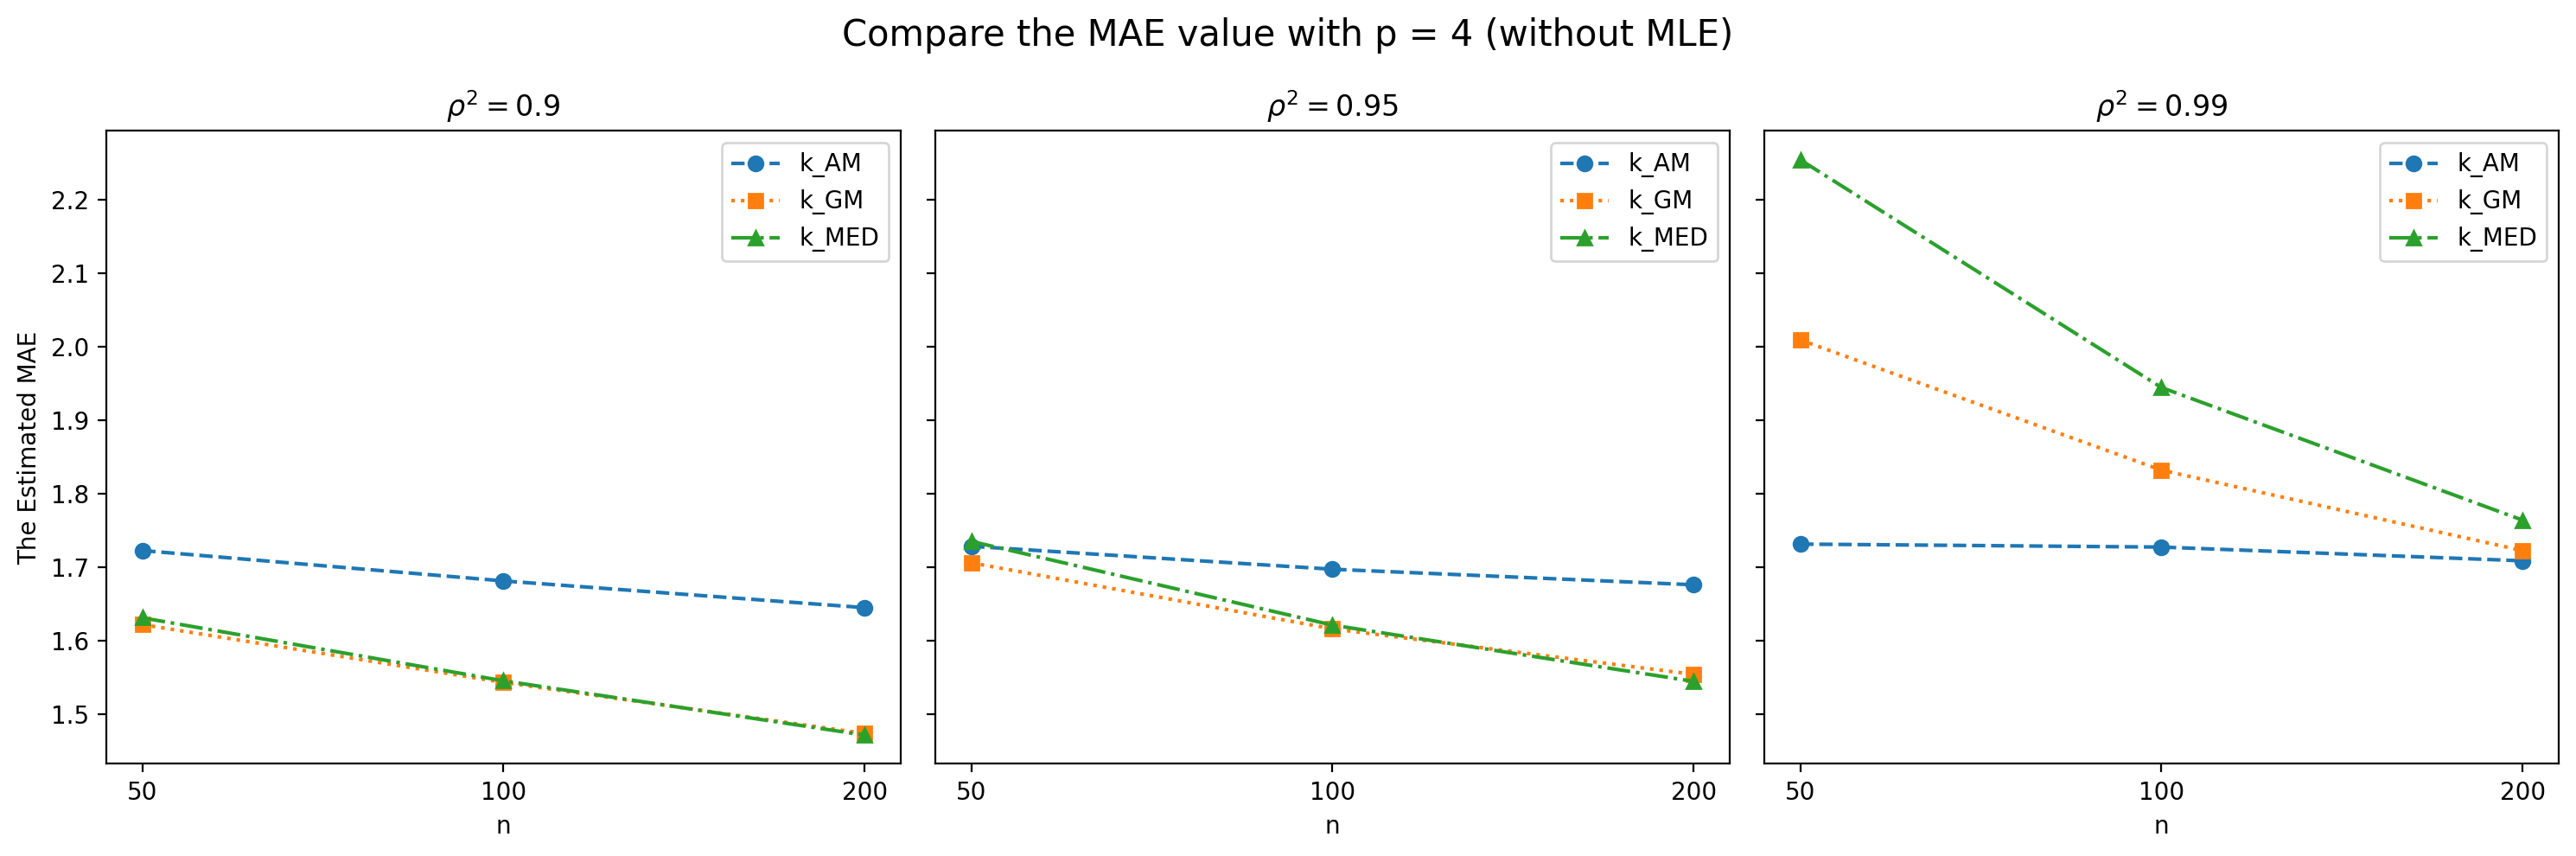

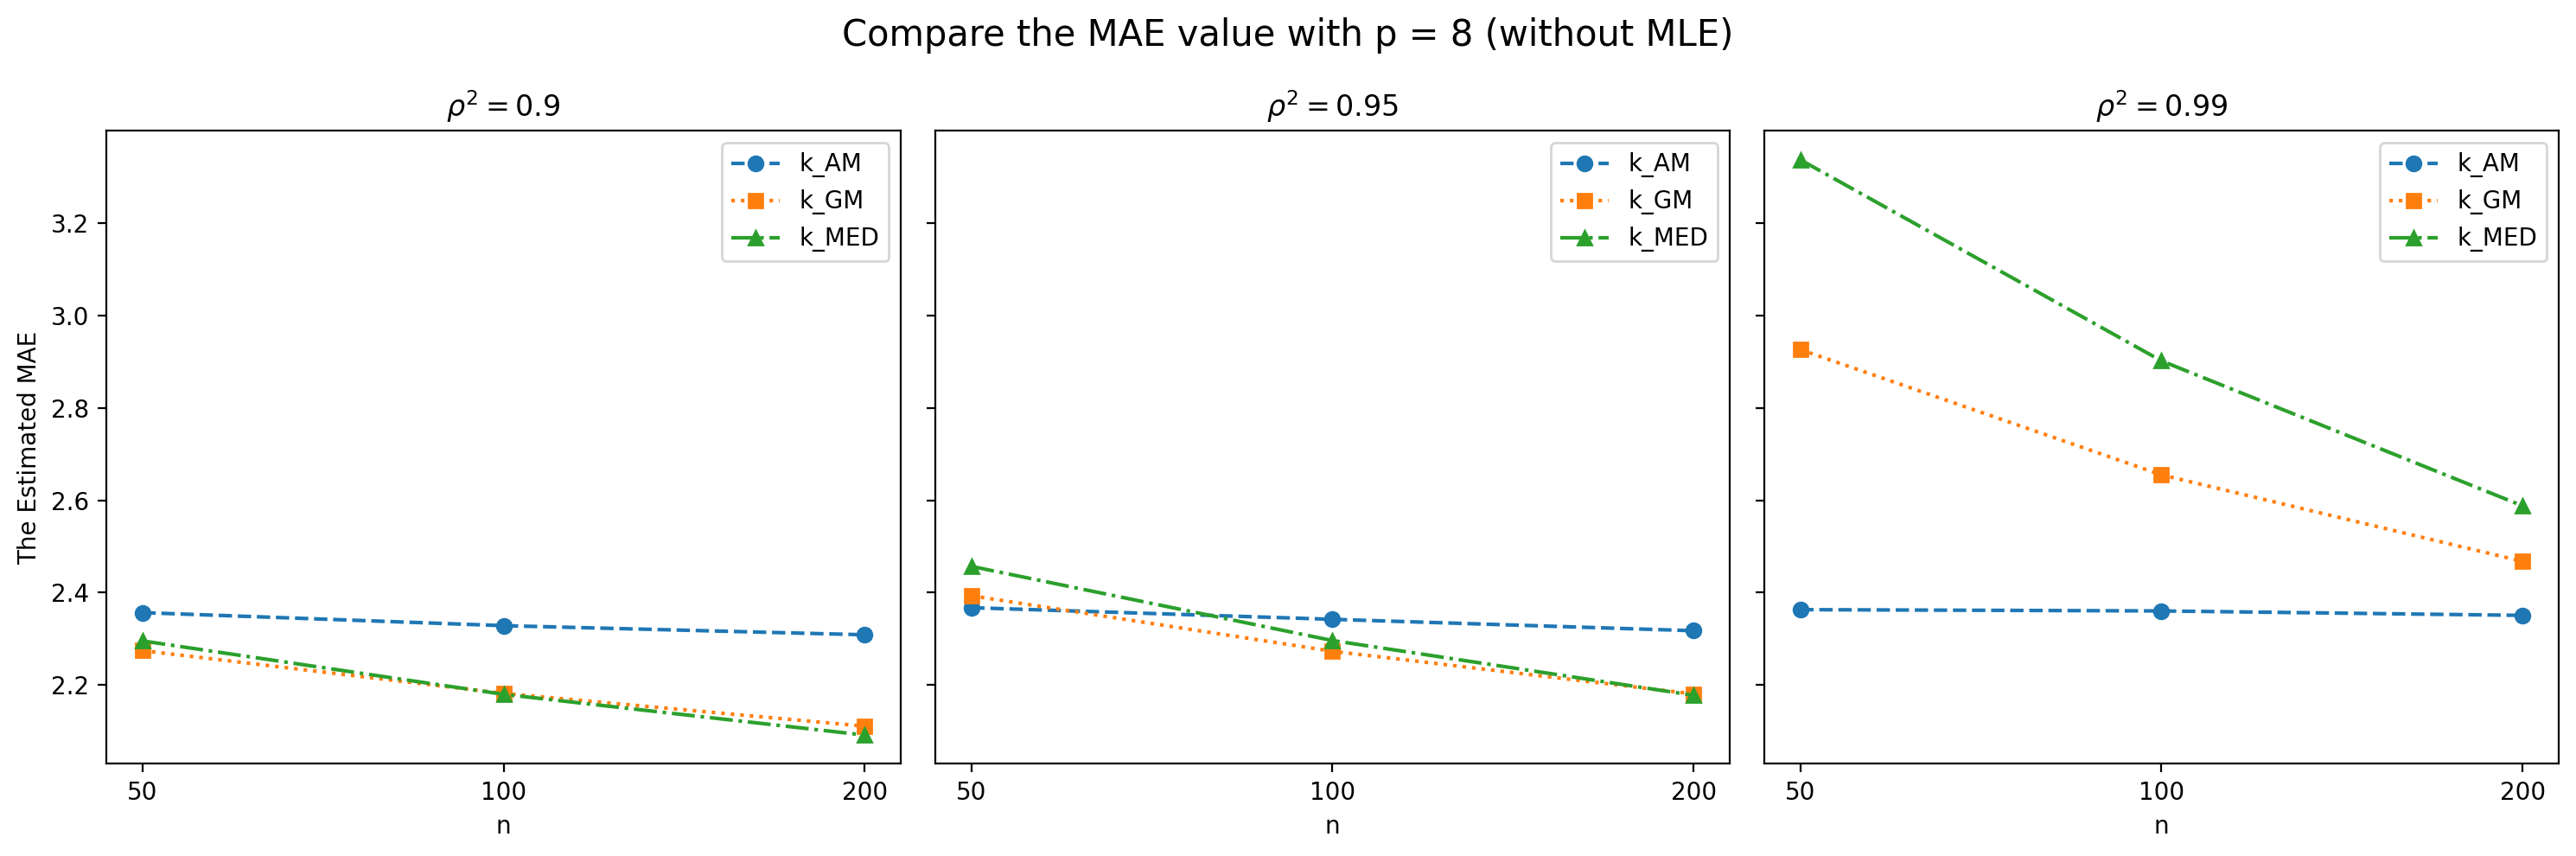

In [5]:
compare = "MAE"
ranges = [(1, 9), (10, 18)]
# plot_mle_options = [False, True]
plot_mle_options = [False]

for start, end in ranges:
    for plot_mle in plot_mle_options:
        plot_figures(compare, start, end, plot_mle)

# Plot the comparison of different RMSE values

In [6]:
file_path = "/Users/pao/Desktop/Intern/output/Asar_LLT/RMSE_Table.xlsx"
df = pd.read_excel(file_path)
df

,Data,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,p,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
1,rho^2,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000
2,n,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000
3,k_AM,0.678386,0.679066,0.679857,0.674056,0.676238,0.677030,0.670155,0.671596,0.672560,0.683121,0.682872,0.682895,0.679029,0.678181,0.679777,0.671596,0.672514,0.674755
4,k_GM,0.665272,0.668390,0.669820,0.661902,0.667584,0.669329,0.661518,0.665311,0.667060,0.664990,0.667430,0.671286,0.661208,0.666406,0.669358,0.661189,0.665290,0.669089
5,k_MED,0.664217,0.669049,0.669708,0.663791,0.667093,0.669595,0.660099,0.665352,0.667994,0.662936,0.667392,0.670407,0.661764,0.666080,0.669091,0.658273,0.664798,0.668698
6,MLE,0.638598,0.655247,0.661678,0.641350,0.654192,0.662661,0.640435,0.656730,0.662237,0.616734,0.644396,0.657525,0.616700,0.645723,0.658147,0.616394,0.646827,0.658689


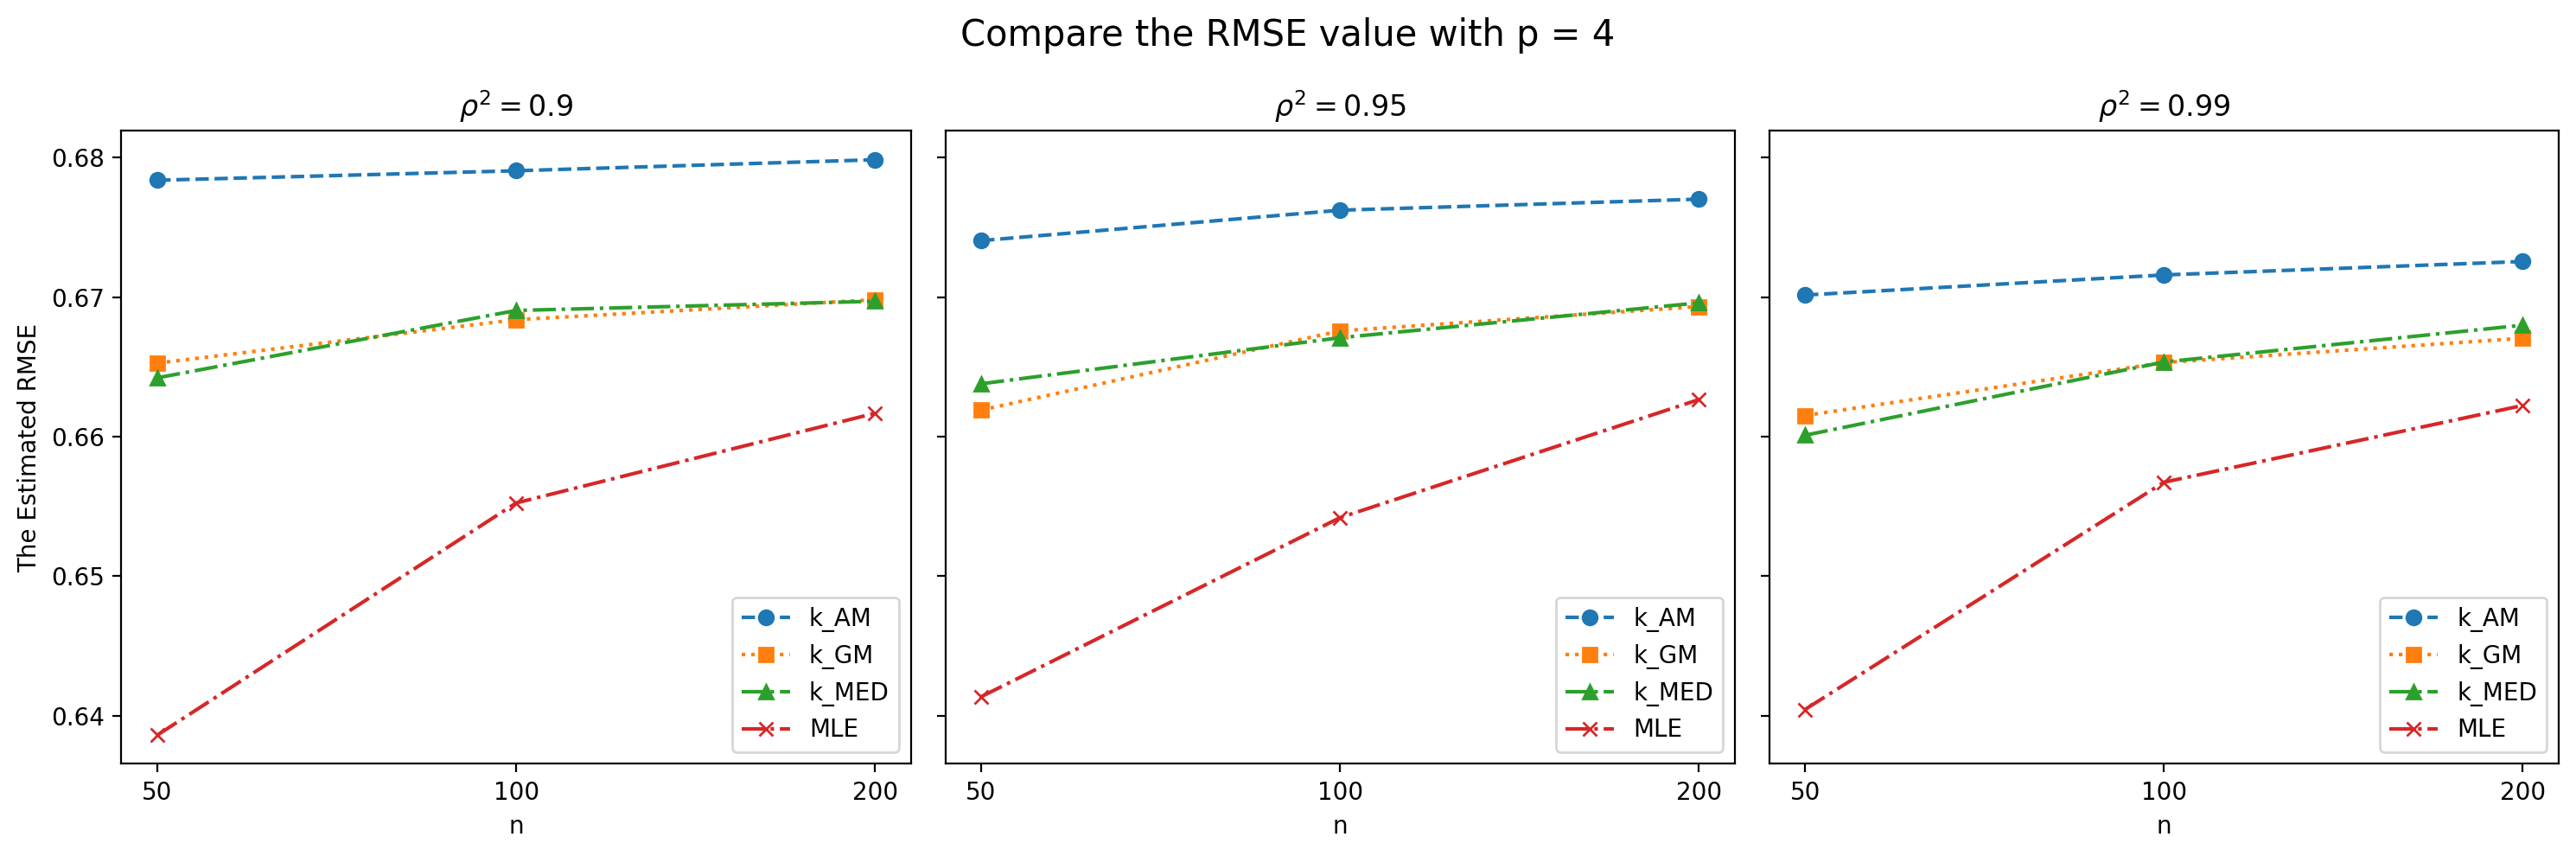

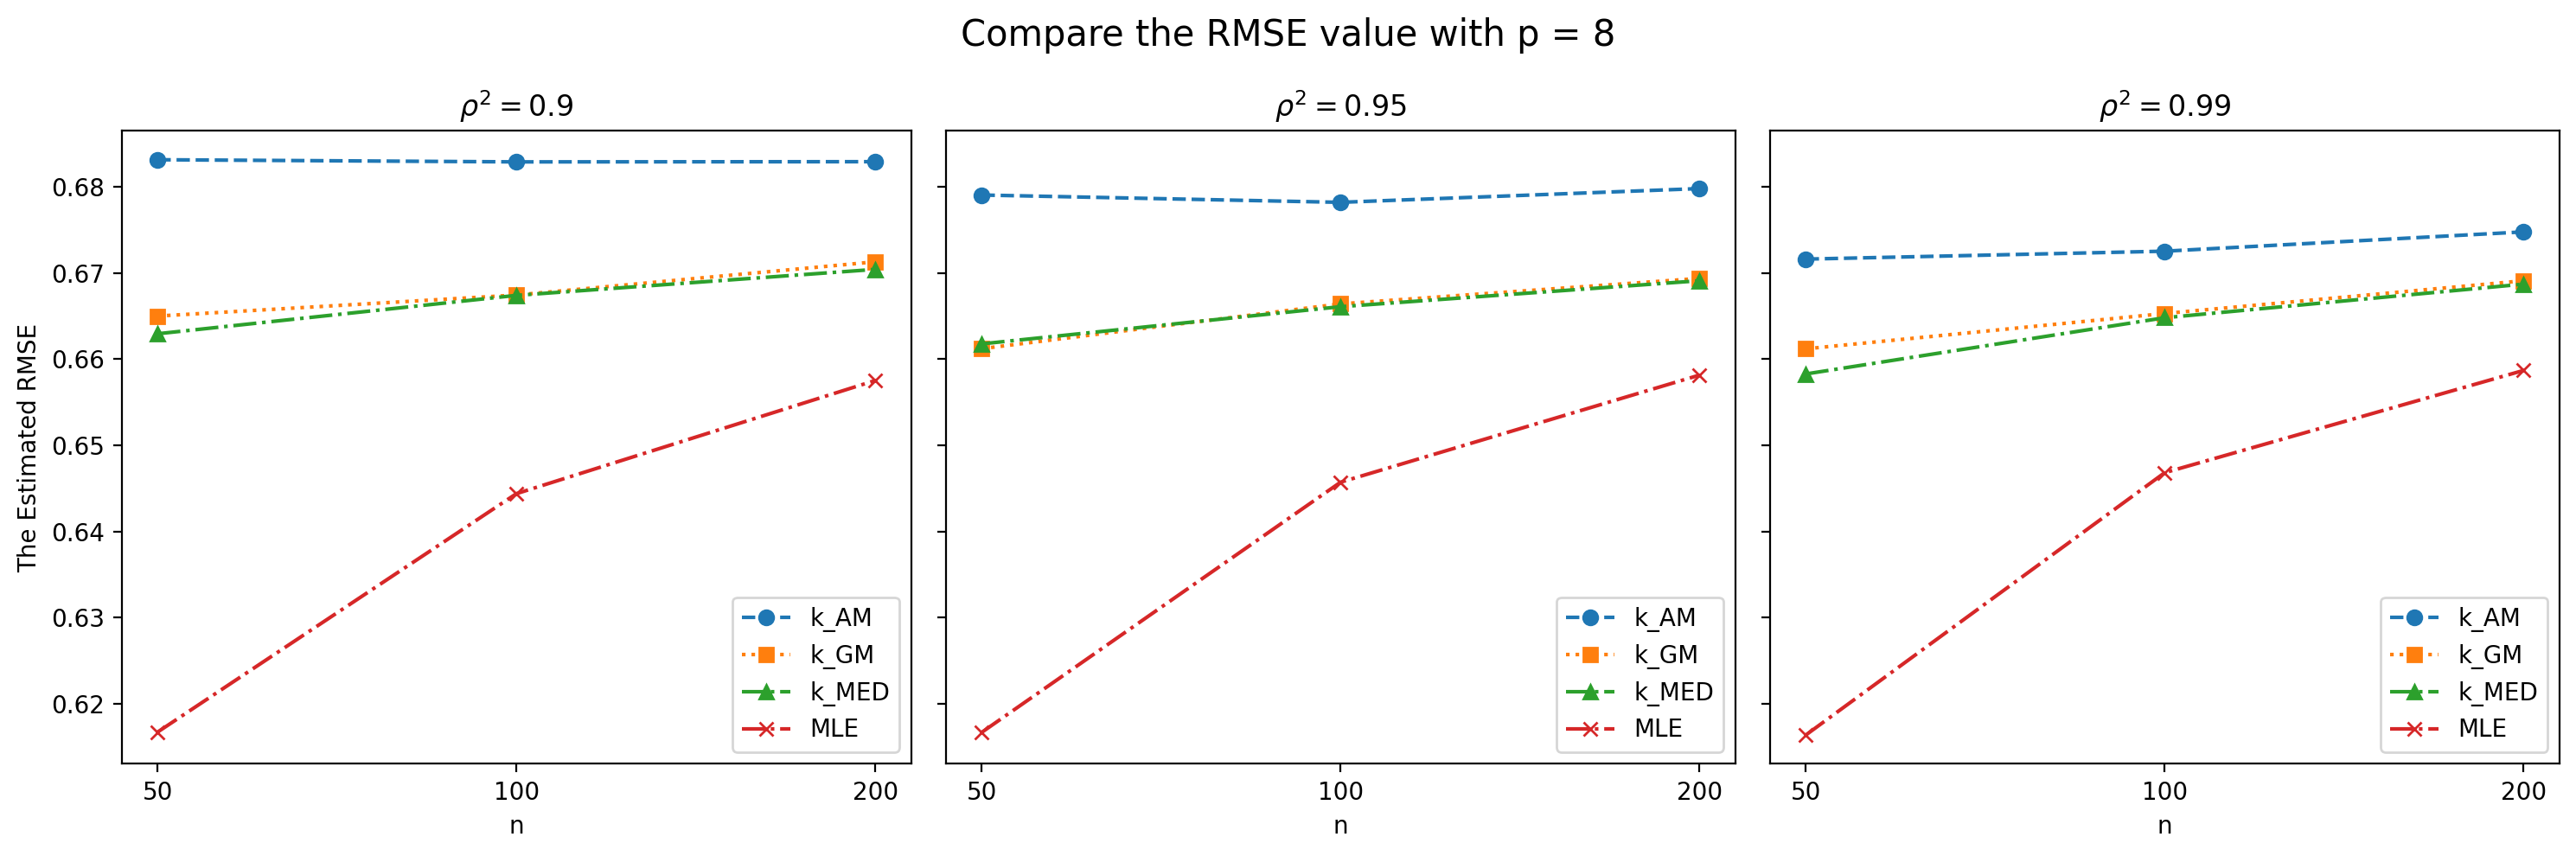

In [7]:
compare = "RMSE"
ranges = [(1, 9), (10, 18)]
plot_mle_options = [True]

for start, end in ranges:
    for plot_mle in plot_mle_options:
        plot_figures(compare, start, end, plot_mle)